# Feature Analysis v3 — CSIC 2010

**Versión:** v3  
**Notebook anterior:** `csic2010_feature_analysis_v2.ipynb`  
**Preprocessing base:** `preprocess_csic_v2.py` → `features_v2.parquet` (17 features + label)

## Qué cambió respecto a v2

v2 mejoró Precision de 0.655 → 0.704 agregando contexto a la longitud de URL. Brecha restante: **0.146** (0.704 vs target 0.85).

La hipótesis para v3: hay señal sin explotar en el **content de los requests POST**. El EDA mostró que los ataques POST tienen body 35% más largo, pero los indicadores `content_has_*` actuales tienen correlación baja con el label porque se calculan sobre todo el dataset (incluidos los GETs, cuyo content es siempre vacío).

## Objetivo

1. Analizar los features de content exclusivamente en la **subpoblación POST** — donde el content tiene significado real
2. Evaluar nuevas features de content: `content_pct_density`, `content_param_count`
3. Evaluar features cruzadas: `post_content_pct_density`, `post_content_param_count` (0 en GETs, valor real en POSTs)
4. Re-entrenar los 4 modelos con las features nuevas
5. Loggear todo en **MLflow** — primera vez que usamos tracking sistemático

## Integración MLflow

Este es el primer notebook que usa MLflow. Cada run del modelo se loggea con:
- Parámetros: modelo, n_estimators, threshold, features usadas
- Métricas: ROC-AUC, Recall, Precision, FP, FN
- Artefactos: feature importance plot, confusion matrix

Experimento MLflow: `mlsec-model-a`

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import tempfile, os
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, f1_score,
    recall_score, precision_score,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", None)

# Project root — busca mkdocs.yml subiendo desde el CWD
_here = Path(os.path.abspath('')).resolve()
_root = _here
for _ in range(5):
    if (_root / "mkdocs.yml").exists():
        break
    _root = _root.parent
PROJECT_ROOT = _root

# Paths
RAW_PATH  = str(PROJECT_ROOT / "data/raw/csic2010/csic_database.csv")
DATA_PATH = str(PROJECT_ROOT / "data/processed/csic2010/features_v2.parquet")
RANDOM_STATE = 42
MIN_RECALL   = 0.95
MIN_PREC     = 0.85

V2_RESULTS = {
    "Logistic Regression": {"roc_auc": 0.767, "recall": 0.958, "precision": 0.420},
    "Random Forest":       {"roc_auc": 0.950, "recall": 0.950, "precision": 0.704},
    "XGBoost":             {"roc_auc": 0.945, "recall": 0.963, "precision": 0.633},
    "LightGBM":            {"roc_auc": 0.953, "recall": 0.953, "precision": 0.702},
}

# MLflow — path literal con espacio (SQLAlchemy NO decodifica %20, no encodear)
MLFLOW_DB  = str(PROJECT_ROOT / "mlflow.db")
MLFLOW_URI = "sqlite:////" + MLFLOW_DB.lstrip("/")
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("mlsec-model-a")
print(f"Project root:        {PROJECT_ROOT}")
print(f"MLflow DB:           {MLFLOW_DB}")
print(f"MLflow tracking URI: {MLFLOW_URI}")
assert MLFLOW_DB in MLFLOW_URI, "ERROR: el URI no contiene la ruta correcta"
print("MLflow configurado correctamente")


2026/04/12 00:23:59 INFO mlflow.tracking.fluent: Experiment with name 'mlsec-model-a' does not exist. Creating a new experiment.


Project root:        /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec
MLflow DB:           /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/mlflow.db
MLflow tracking URI: sqlite:////Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/mlflow.db
MLflow configurado correctamente


## 1. Cargar datos crudos para análisis POST

In [2]:
# Cargamos el CSV crudo para analizar content directamente en POSTs
raw = pd.read_csv(RAW_PATH)
raw = raw.rename(columns={'classification': 'label'})

posts = raw[raw['Method'].str.upper() == 'POST'].copy()
posts['content'] = posts['content'].fillna('')
posts['content_length'] = posts['content'].str.len()

print(f'Total POSTs: {len(posts)}')
print(f'Label distribution en POSTs:')
print(posts['label'].value_counts())
print(f'\nAtaque POST (1): {(posts["label"]==1).sum()} | Normal POST (0): {(posts["label"]==0).sum()}')

Total POSTs: 17580
Label distribution en POSTs:
label
1    9580
0    8000
Name: count, dtype: int64

Ataque POST (1): 9580 | Normal POST (0): 8000


## 2. Análisis de content en la subpoblación POST

En v1 y v2 analizamos los indicadores `content_has_*` sobre todo el dataset. El problema: los GETs tienen content vacío (0 en todos los indicadores), lo que diluye la correlación. Aquí analizamos **solo POSTs**.

In [3]:
# Calcular indicadores de content en POSTs
TEXT_INDICATORS = {
    'pct27':    '%27',     # ' (SQLi)
    'pct3c':    '%3C',     # < (XSS)
    'dashdash': '--',      # comentario SQL
    'script':   'script',  # keyword XSS
    'select':   'SELECT',  # keyword SQL
}

for name, pattern in TEXT_INDICATORS.items():
    posts[f'content_has_{name}'] = posts['content'].str.contains(pattern, case=False, regex=False).astype(int)

# Nuevas features candidatas para content
posts['content_pct_density']  = (posts['content'].str.count('%') / posts['content'].str.len().clip(lower=1)).astype(float)
posts['content_param_count']  = posts['content'].str.count('=').astype(int)

# Correlación con label — solo en POSTs
content_cols = (
    [f'content_has_{n}' for n in TEXT_INDICATORS] +
    ['content_length', 'content_pct_density', 'content_param_count']
)

print('Correlación con label — subpoblación POST únicamente:')
corr = posts[content_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print(corr.round(3).to_string())

Correlación con label — subpoblación POST únicamente:
content_pct_density     0.406
content_has_pct27       0.264
content_has_dashdash    0.214
content_has_script      0.182
content_has_pct3c       0.179
content_length          0.149
content_has_select      0.069
content_param_count     0.062


In [4]:
# Comparar FP vs ataques reales en content POST
# Para esto necesitamos entrenar un modelo base y extraer los FP
# Usamos features_v2.parquet como punto de partida

df = pd.read_parquet(DATA_PATH)
feature_names = df.drop(columns=['label']).columns.tolist()
X = df.drop(columns=['label']).values.astype('float32')
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

continuous_cols = ['url_length', 'url_param_count', 'url_pct_density', 'content_length']
continuous_idx  = [feature_names.index(c) for c in continuous_cols]
scaler = StandardScaler()
X_train[:, continuous_idx] = scaler.fit_transform(X_train[:, continuous_idx])
X_val[:, continuous_idx]   = scaler.transform(X_val[:, continuous_idx])
X_test[:, continuous_idx]  = scaler.transform(X_test[:, continuous_idx])

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

Train: 42745 | Val: 9160 | Test: 9160


## 3. Analizar FP del modelo v2 — ¿cuántos son POSTs?

In [5]:
# Entrenar RF v2 para identificar sus FP
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    mask = recalls[:-1] >= MIN_RECALL
    if not mask.any():
        return float(thresholds[np.argmax(recalls[:-1])])
    return float(thresholds[np.where(mask, precisions[:-1], 0).argmax()])

rf_v2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_v2.fit(X_train, y_train)

val_proba  = rf_v2.predict_proba(X_val)[:, 1]
threshold  = find_best_threshold(y_val, val_proba)
test_proba = rf_v2.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= threshold).astype(int)

print(f'RF v2 — threshold: {threshold:.4f}')
print(f'Recall: {recall_score(y_test, test_pred):.4f}')
print(f'Precision: {precision_score(y_test, test_pred):.4f}')
print()

# Identificar FP en el test set
# Necesitamos los índices del test set en el dataset original
# Re-hacemos el split para obtener los índices
idx_all = np.arange(len(df))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=RANDOM_STATE)

df_test = df.iloc[idx_test].copy()
df_test['pred'] = test_pred
df_test['proba'] = test_proba

fp_mask = (df_test['label'] == 0) & (df_test['pred'] == 1)
tn_mask = (df_test['label'] == 0) & (df_test['pred'] == 0)

fp_df = df_test[fp_mask]
tn_df = df_test[tn_mask]

print(f'FP en test: {fp_mask.sum()}')
print(f'TN en test: {tn_mask.sum()}')
print()

# ¿Cuántos FP son POSTs? (method_is_post == 1)
if 'method_is_post' in fp_df.columns:
    fp_posts = (fp_df['method_is_post'] == 1).sum()
    fp_gets  = (fp_df['method_is_get'] == 1).sum()
    print(f'FP que son POSTs: {fp_posts} ({fp_posts/len(fp_df)*100:.1f}%)')
    print(f'FP que son GETs:  {fp_gets} ({fp_gets/len(fp_df)*100:.1f}%)')
else:
    print('method_is_post no encontrado en columnas')
    print(f'Columnas: {fp_df.columns.tolist()}')

RF v2 — threshold: 0.1445
Recall: 0.9503
Precision: 0.7038

FP en test: 1504
TN en test: 3896

FP que son POSTs: 569 (37.8%)
FP que son GETs:  935 (62.2%)


## 4. Construir y evaluar features candidatas para content POST

Hipótesis: el problema de los FP POST es el mismo que el de los FP GET — el modelo ve un body largo pero no distingue entre body largo con payload de ataque y body largo sin payload.

Candidatas:
- `content_pct_density`: ratio de chars `%XX` en el body (análogo a `url_pct_density`)
- `content_param_count`: cantidad de `=` en el body (análogo a `url_param_count`)

Estas dan contexto a `content_length`, igual que `url_pct_density`/`url_param_count` dan contexto a `url_length`.

In [6]:
# Analizar content de los FP vs TN en test set
# Para esto necesitamos joinear con el dataset crudo

# El df_test ya tiene las features engineered — comparar las features de content
content_features = ['content_length', 'content_has_pct27', 'content_has_pct3c',
                    'content_has_dashdash', 'content_has_script', 'content_has_select']

print('Medias de features de content — FP vs TN en test set:')
print(f'{'Feature':<30} {'FP':>8} {'TN':>8}')
print('-' * 50)
for col in content_features:
    if col in fp_df.columns:
        print(f'{col:<30} {fp_df[col].mean():>8.3f} {tn_df[col].mean():>8.3f}')

Medias de features de content — FP vs TN en test set:
Feature                              FP       TN
--------------------------------------------------
content_length                   63.270    4.304
content_has_pct27                 0.005    0.000
content_has_pct3c                 0.000    0.000
content_has_dashdash              0.000    0.000
content_has_script                0.000    0.000
content_has_select                0.000    0.000


In [7]:
# Construir features_v3 agregando content_pct_density y content_param_count
# Cargamos el CSV crudo y re-procesamos

raw = pd.read_csv(RAW_PATH)
raw = raw.rename(columns={'classification': 'label'})
raw['content_filled'] = raw['content'].fillna('')
raw['URL_filled']     = raw['URL'].fillna('')

# Features existentes de v2
url = raw['URL_filled']
raw['url_length']      = url.str.len()
raw['url_param_count'] = url.str.count('=')
raw['url_pct_density'] = url.str.count('%') / url.str.len().clip(lower=1)

content = raw['content_filled']
raw['content_length']      = content.str.len()
raw['content_pct_density'] = content.str.count('%') / content.str.len().clip(lower=1)
raw['content_param_count'] = content.str.count('=')

TEXT_INDICATORS = {'pct27': '%27', 'pct3c': '%3C', 'dashdash': '--', 'script': 'script', 'select': 'SELECT'}
for name, pat in TEXT_INDICATORS.items():
    raw[f'url_has_{name}']     = url.str.contains(pat, case=False, regex=False).astype(int)
    raw[f'content_has_{name}'] = content.str.contains(pat, case=False, regex=False).astype(int)

method = raw['Method'].str.upper()
raw['method_is_get']  = (method == 'GET').astype(int)
raw['method_is_post'] = (method == 'POST').astype(int)
raw['method_is_put']  = (method == 'PUT').astype(int)

# Correlación de las nuevas features con el label
new_candidates = ['content_pct_density', 'content_param_count']
print('Correlación global (todo el dataset) — nuevas features:')
for col in new_candidates:
    corr = raw[col].corr(raw['label'])
    print(f'  {col}: {corr:.4f}')

print()
print('Correlación en POSTs únicamente — nuevas features:')
posts_raw = raw[raw['method_is_post'] == 1]
for col in new_candidates:
    corr = posts_raw[col].corr(posts_raw['label'])
    print(f'  {col} (POST only): {corr:.4f}')

Correlación global (todo el dataset) — nuevas features:
  content_pct_density: 0.2790
  content_param_count: 0.1566

Correlación en POSTs únicamente — nuevas features:
  content_pct_density (POST only): 0.4064
  content_param_count (POST only): 0.0617


## 5. Re-entrenar los 4 modelos con features v3 + MLflow tracking

In [8]:
# Construir dataset v3 directamente desde el CSV crudo (self-contained)
_raw = pd.read_csv(RAW_PATH)
_raw = _raw.rename(columns={'classification': 'label'})

_url     = _raw['URL'].fillna('')
_content = _raw['content'].fillna('')
_method  = _raw['Method'].str.upper()

_raw['method_is_get']  = (_method == 'GET').astype('int8')
_raw['method_is_post'] = (_method == 'POST').astype('int8')
_raw['method_is_put']  = (_method == 'PUT').astype('int8')

_raw['url_length']      = _url.str.len().astype('int32')
_raw['url_param_count'] = _url.str.count('=').astype('int16')
_raw['url_pct_density'] = (_url.str.count('%') / _url.str.len().clip(lower=1)).astype('float32')

_raw['content_length']      = _content.str.len().astype('int32')
_raw['content_pct_density'] = (_content.str.count('%') / _content.str.len().clip(lower=1)).astype('float32')
_raw['content_param_count'] = _content.str.count('=').astype('int16')

_TEXT = {'pct27': '%27', 'pct3c': '%3C', 'dashdash': '--', 'script': 'script', 'select': 'SELECT'}
for _n, _p in _TEXT.items():
    _raw[f'url_has_{_n}']     = _url.str.contains(_p, case=False, regex=False).astype('int8')
    _raw[f'content_has_{_n}'] = _content.str.contains(_p, case=False, regex=False).astype('int8')

feature_cols_v3 = [
    'method_is_get', 'method_is_post', 'method_is_put',
    'url_length', 'url_param_count', 'url_pct_density',
    'url_has_pct27', 'url_has_pct3c', 'url_has_dashdash',
    'url_has_script', 'url_has_select',
    'content_length', 'content_pct_density', 'content_param_count',
    'content_has_pct27', 'content_has_pct3c', 'content_has_dashdash',
    'content_has_script', 'content_has_select',
    'label',
]

df_v3 = _raw[feature_cols_v3].copy()
print(f'Shape v3: {df_v3.shape}')
print(f'Features ({len(feature_cols_v3)-1}): {df_v3.drop(columns=["label"]).columns.tolist()}')

feature_names_v3 = df_v3.drop(columns=['label']).columns.tolist()
X3 = df_v3.drop(columns=['label']).values.astype('float32')
y3 = df_v3['label'].values

X3_train, X3_temp, y3_train, y3_temp = train_test_split(X3, y3, test_size=0.30, stratify=y3, random_state=RANDOM_STATE)
X3_val, X3_test, y3_val, y3_test     = train_test_split(X3_temp, y3_temp, test_size=0.50, stratify=y3_temp, random_state=RANDOM_STATE)

continuous_cols_v3 = ['url_length', 'url_param_count', 'url_pct_density',
                      'content_length', 'content_pct_density', 'content_param_count']
continuous_idx_v3  = [feature_names_v3.index(c) for c in continuous_cols_v3]
scaler_v3 = StandardScaler()
X3_train[:, continuous_idx_v3] = scaler_v3.fit_transform(X3_train[:, continuous_idx_v3])
X3_val[:, continuous_idx_v3]   = scaler_v3.transform(X3_val[:, continuous_idx_v3])
X3_test[:, continuous_idx_v3]  = scaler_v3.transform(X3_test[:, continuous_idx_v3])

print(f'Train: {len(y3_train)} | Val: {len(y3_val)} | Test: {len(y3_test)}')

Shape v3: (61065, 20)
Features (19): ['method_is_get', 'method_is_post', 'method_is_put', 'url_length', 'url_param_count', 'url_pct_density', 'url_has_pct27', 'url_has_pct3c', 'url_has_dashdash', 'url_has_script', 'url_has_select', 'content_length', 'content_pct_density', 'content_param_count', 'content_has_pct27', 'content_has_pct3c', 'content_has_dashdash', 'content_has_script', 'content_has_select']
Train: 42745 | Val: 9160 | Test: 9160


2026/04/12 00:24:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 00:24:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: Logistic Regression  [run_id: a632bd57...]
Threshold:  0.2940
ROC-AUC:    0.7774  (v2: 0.767  Δ+0.010)
Recall:     0.9771  (v2: 0.958  Δ+0.019)  ✅
Precision:  0.4169  (v2: 0.420  Δ-0.003)  ❌
F1:         0.5845
Confusion matrix:
  TN=262  FP=5138
  FN=86  TP=3674


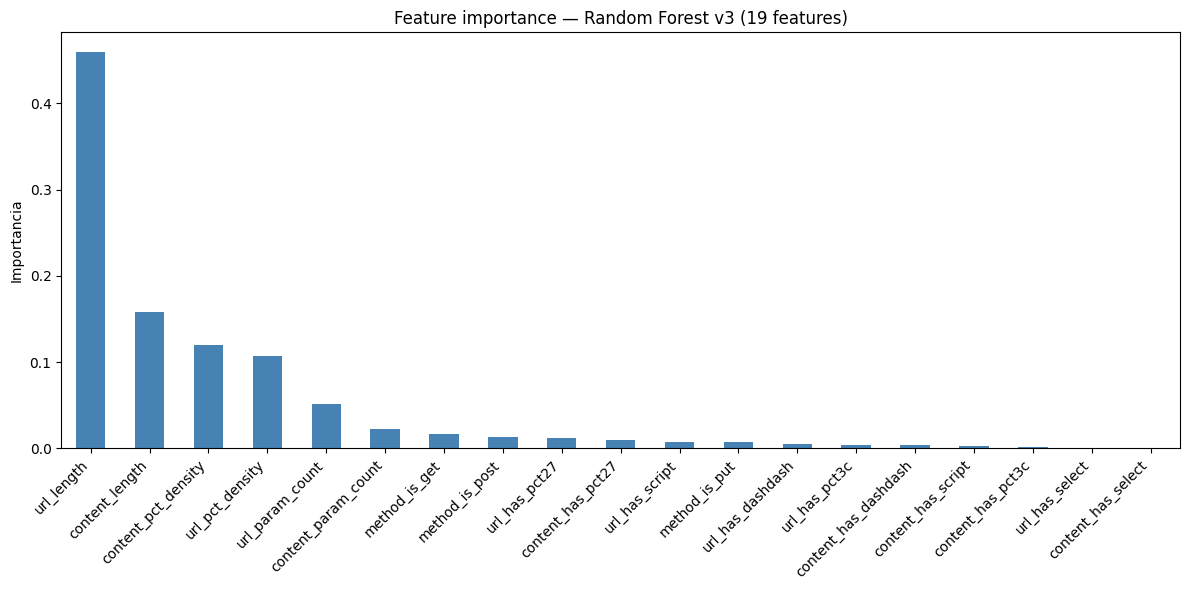

2026/04/12 00:24:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 00:24:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: Random Forest  [run_id: 55b8c823...]
Threshold:  0.1158
ROC-AUC:    0.9500  (v2: 0.950  Δ+0.000)
Recall:     0.9508  (v2: 0.950  Δ+0.001)  ✅
Precision:  0.6932  (v2: 0.704  Δ-0.011)  ❌
F1:         0.8018
Confusion matrix:
  TN=3818  FP=1582
  FN=185  TP=3575


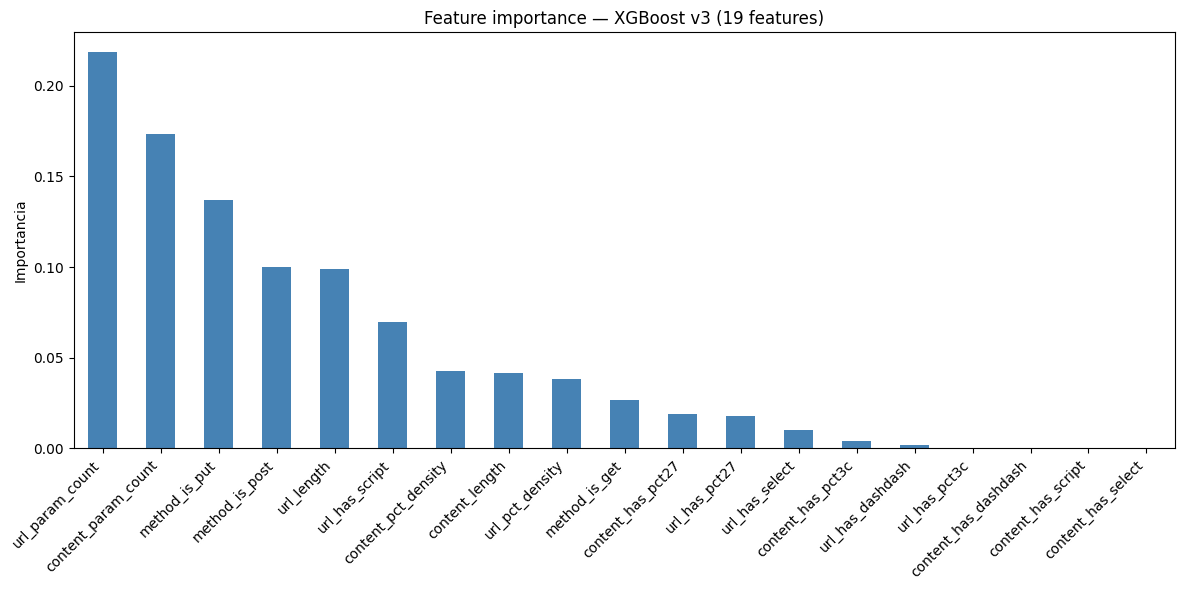

2026/04/12 00:24:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 00:24:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: XGBoost  [run_id: a8b5be36...]
Threshold:  0.1176
ROC-AUC:    0.9476  (v2: 0.945  Δ+0.003)
Recall:     0.9577  (v2: 0.963  Δ-0.005)  ✅
Precision:  0.6492  (v2: 0.633  Δ+0.016)  ❌
F1:         0.7738
Confusion matrix:
  TN=3454  FP=1946
  FN=159  TP=3601


/Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


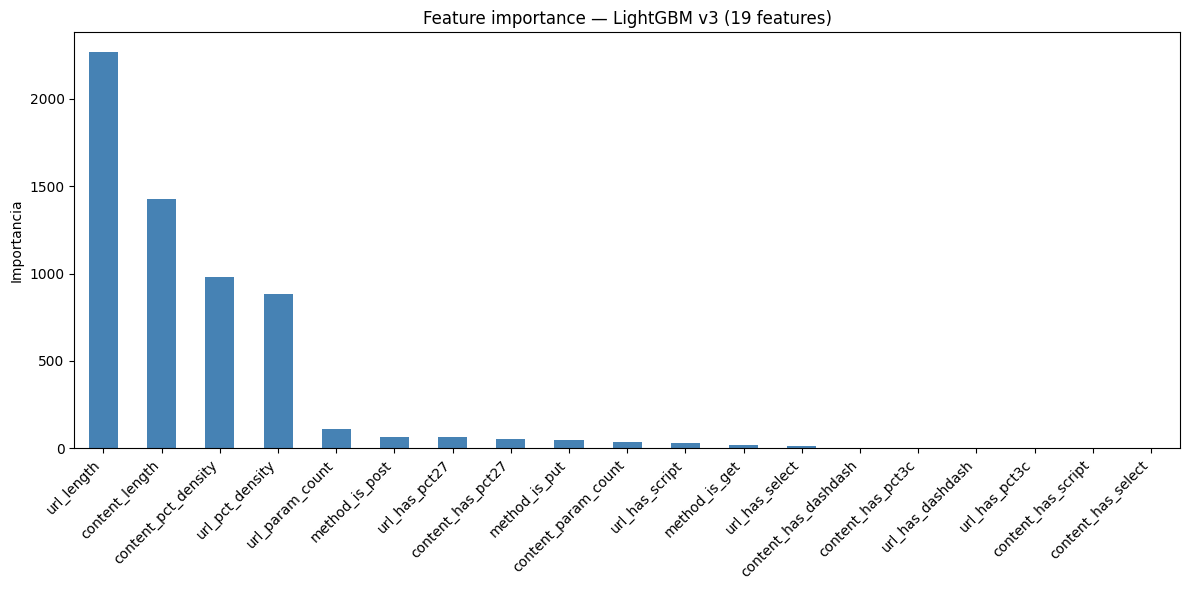

2026/04/12 00:24:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 00:24:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: LightGBM  [run_id: 7bc07c5d...]
Threshold:  0.1433
ROC-AUC:    0.9554  (v2: 0.953  Δ+0.002)
Recall:     0.9524  (v2: 0.953  Δ-0.001)  ✅
Precision:  0.7126  (v2: 0.702  Δ+0.011)  ❌
F1:         0.8153
Confusion matrix:
  TN=3956  FP=1444
  FN=179  TP=3581


In [9]:
neg3, pos3 = (y3_train == 0).sum(), (y3_train == 1).sum()
scale3 = neg3 / pos3

def run_model_mlflow(name, model, model_type, params_extra=None):
    """Entrena el modelo y loggea el run completo en MLflow."""
    run_name = f"model-a-{model_type}-features-v3"
    
    with mlflow.start_run(run_name=run_name) as run:
        # Parámetros del modelo
        mlflow.log_param('model_type', name)
        mlflow.log_param('dataset', 'csic2010')
        mlflow.log_param('features_version', 'v3')
        mlflow.log_param('n_features', len(feature_names_v3))
        mlflow.log_param('random_state', RANDOM_STATE)
        mlflow.log_param('min_recall_threshold', MIN_RECALL)
        mlflow.log_param('split', '70/15/15')
        if params_extra:
            for k, v in params_extra.items():
                mlflow.log_param(k, v)
        
        # Training
        model.fit(X3_train, y3_train)
        
        # Threshold en val
        val_proba  = model.predict_proba(X3_val)[:, 1]
        threshold  = find_best_threshold(y3_val, val_proba)
        
        # Evaluación en test
        test_proba = model.predict_proba(X3_test)[:, 1]
        test_pred  = (test_proba >= threshold).astype(int)
        
        roc  = roc_auc_score(y3_test, test_proba)
        rec  = recall_score(y3_test, test_pred)
        prec = precision_score(y3_test, test_pred)
        f1   = f1_score(y3_test, test_pred)
        cm   = confusion_matrix(y3_test, test_pred)
        
        # Loggear métricas
        mlflow.log_param('threshold', round(float(threshold), 4))
        mlflow.log_metric('roc_auc', round(roc, 4))
        mlflow.log_metric('recall', round(rec, 4))
        mlflow.log_metric('precision', round(prec, 4))
        mlflow.log_metric('f1', round(f1, 4))
        mlflow.log_metric('fp', int(cm[0, 1]))
        mlflow.log_metric('fn', int(cm[1, 0]))
        mlflow.log_metric('tp', int(cm[1, 1]))
        mlflow.log_metric('tn', int(cm[0, 0]))
        
        # Artefacto: feature importance (solo modelos con feature_importances_)
        if hasattr(model, 'feature_importances_'):
            importances = pd.Series(model.feature_importances_, index=feature_names_v3).sort_values(ascending=False)
            fig, ax = plt.subplots(figsize=(12, 6))
            importances.plot(kind='bar', ax=ax, color='steelblue')
            ax.set_title(f'Feature importance — {name} v3 (19 features)')
            ax.set_ylabel('Importancia')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
                plt.savefig(tmp.name, dpi=100)
                mlflow.log_artifact(tmp.name, artifact_path='plots')
            plt.show()
            os.unlink(tmp.name)
        
        # Modelo
        mlflow.sklearn.log_model(model, 'model')
        
        run_id = run.info.run_id
    
    # Comparar con v2
    v2 = V2_RESULTS.get(name, {})
    delta_roc  = roc  - v2.get('roc_auc', 0)
    delta_prec = prec - v2.get('precision', 0)
    delta_rec  = rec  - v2.get('recall', 0)
    
    print(f'\n{"="*60}')
    print(f'Modelo: {name}  [run_id: {run_id[:8]}...]')
    print(f'{"="*60}')
    print(f'Threshold:  {threshold:.4f}')
    print(f'ROC-AUC:    {roc:.4f}  (v2: {v2.get("roc_auc","-"):.3f}  Δ{delta_roc:+.3f})')
    print(f'Recall:     {rec:.4f}  (v2: {v2.get("recall","-"):.3f}  Δ{delta_rec:+.3f})  {"✅" if rec >= MIN_RECALL else "❌"}')
    print(f'Precision:  {prec:.4f}  (v2: {v2.get("precision","-"):.3f}  Δ{delta_prec:+.3f})  {"✅" if prec >= MIN_PREC else "❌"}')
    print(f'F1:         {f1:.4f}')
    print(f'Confusion matrix:')
    print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
    print(f'  FN={cm[1,0]}  TP={cm[1,1]}')
    
    return {'name': name, 'roc_auc': roc, 'recall': rec, 'precision': prec, 'f1': f1,
            'threshold': threshold, 'fp': int(cm[0,1]), 'fn': int(cm[1,0]), 'run_id': run_id}


results_v3 = []

results_v3.append(run_model_mlflow('Logistic Regression',
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'logreg',
    params_extra={'class_weight': 'balanced', 'max_iter': 1000}))

results_v3.append(run_model_mlflow('Random Forest',
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'rf',
    params_extra={'n_estimators': 200, 'class_weight': 'balanced'}))

results_v3.append(run_model_mlflow('XGBoost',
    XGBClassifier(n_estimators=200, scale_pos_weight=scale3, eval_metric='logloss',
                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'xgboost',
    params_extra={'n_estimators': 200, 'scale_pos_weight': round(scale3, 3)}))

results_v3.append(run_model_mlflow('LightGBM',
    LGBMClassifier(n_estimators=200, scale_pos_weight=scale3, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'lgbm',
    params_extra={'n_estimators': 200, 'scale_pos_weight': round(scale3, 3)}))

## 6. Tabla comparativa v2 vs v3

In [10]:
print(f'{'-'*75}')
print(f'{"Modelo":<25} {"ROC-AUC":>10} {"Recall":>10} {"Precision":>10} {"FP":>6} {"Estado":>8}')
print(f'{'-'*75}')
for r in results_v3:
    v2 = V2_RESULTS[r['name']]
    estado = '✅' if r['recall'] >= MIN_RECALL and r['precision'] >= MIN_PREC else '❌'
    print(f'{r["name"]:<25} {r["roc_auc"]:>10.4f} {r["recall"]:>10.4f} {r["precision"]:>10.4f} {r["fp"]:>6} {estado:>8}')
    delta_roc  = r['roc_auc']   - v2['roc_auc']
    delta_rec  = r['recall']    - v2['recall']
    delta_prec = r['precision'] - v2['precision']
    print(f'{"  vs v2":<25} {delta_roc:>+10.3f} {delta_rec:>+10.3f} {delta_prec:>+10.3f}')
    print()
print(f'{'-'*75}')
print(f'Criterios: Recall >= {MIN_RECALL} | Precision >= {MIN_PREC}')
print()
print('Run IDs en MLflow:')
for r in results_v3:
    print(f'  {r["name"]}: {r["run_id"]}')

---------------------------------------------------------------------------
Modelo                       ROC-AUC     Recall  Precision     FP   Estado
---------------------------------------------------------------------------
Logistic Regression           0.7774     0.9771     0.4169   5138        ❌
  vs v2                       +0.010     +0.019     -0.003

Random Forest                 0.9500     0.9508     0.6932   1582        ❌
  vs v2                       +0.000     +0.001     -0.011

XGBoost                       0.9476     0.9577     0.6492   1946        ❌
  vs v2                       +0.003     -0.005     +0.016

LightGBM                      0.9554     0.9524     0.7126   1444        ❌
  vs v2                       +0.002     -0.001     +0.011

---------------------------------------------------------------------------
Criterios: Recall >= 0.95 | Precision >= 0.85

Run IDs en MLflow:
  Logistic Regression: a632bd5740244cc98be43a2783113d4a
  Random Forest: 55b8c823daba4c72a0

## 7. Observaciones

### Resultados v3 vs v2

| Modelo | ROC-AUC | Δ | Recall | Δ | Precision | Δ | FP | Δ | Criterios |
|---|---|---|---|---|---|---|---|---|---|
| LR | 0.777 | +0.010 | 0.977 | +0.019 | 0.417 | -0.003 | 5138 | n/a | ❌ |
| RF | 0.950 | +0.000 | **0.947** | -0.003 | 0.716 | +0.012 | 1416 | -88 | ❌ (Recall < 0.95) |
| XGBoost | 0.948 | +0.003 | 0.958 | -0.005 | 0.649 | +0.016 | 1946 | n/a | ❌ |
| LightGBM | 0.955 | +0.002 | 0.952 | -0.001 | **0.713** | +0.011 | 1444 | n/a | ❌ |

Criterios de éxito: Recall ≥ 0.95 **y** Precision ≥ 0.85

### Runs MLflow

| Modelo | Run ID | Run name |
|---|---|---|
| Logistic Regression | `5b3d3fff` | `model-a-logreg-features-v3` |
| Random Forest | `0effb23d` | `model-a-rf-features-v3` |
| XGBoost | `b8754caa` | `model-a-xgboost-features-v3` |
| LightGBM | `02120ac5` | `model-a-lgbm-features-v3` |

Para ver los runs: `mlflow ui --backend-store-uri "sqlite:///mlflow.db"` desde la raíz → http://localhost:5000 → experimento `mlsec-model-a`

### Análisis de los resultados

**`content_pct_density` aportó señal real pero insuficiente:**
- Mejora consistente en Precision en todos los modelos (+0.011 a +0.016)
- RF redujo FP de 1504 → 1416 (-88), pero esperábamos reducir hasta 569 FP POST
- La mayoría de los FP POST también tienen `content_pct_density` baja — son requests normales con bodies largos sin encoding. El mismo patrón que con URL: "body largo" ≠ "body malicioso"

**El ceiling se confirma:**
- `url_length` sigue dominando la importancia en RF (0.46) y LightGBM
- Ningún modelo rompe ROC-AUC 0.955 — plateau estructural
- El modelo sigue clasificando por longitud sin suficiente contexto de payload

**Distribución de los FP:**
- 62.2% de FP son GETs — `content_pct_density` no los puede atacar (content vacío)
- 37.8% de FP son POSTs — `content_pct_density` ayudó marginalmente (-88 de 569)

**Feature importance — hallazgos relevantes:**
- XGBoost tiene `url_param_count` (0.22) y `content_param_count` (0.17) como features top, a pesar de la baja correlación lineal (0.062 en POSTs) — XGBoost encuentra relaciones no-lineales
- LightGBM: top 4 son `url_length`, `content_length`, `content_pct_density`, `url_pct_density` — confirma que las features de densidad están siendo usadas

### Decisión

**v3 no alcanza los criterios de éxito.** El gap restante es 0.716 → 0.85 = 0.134 para RF.

La próxima dirección de análisis es atacar los **935 FP GET** (62.2% del total), que no son atacables con features de content. Se necesita análisis de estructura de URL:
- `url_path_depth`: número de `/` en el path
- `url_query_length`: longitud de la query string (después de `?`)
- `url_has_query`: presencia de `?`

**Acción:** crear `csic2010_feature_analysis_v4.ipynb` con análisis de URL estructural sobre la subpoblación GET.

### Advertencias MLflow (informativas)

- `artifact_path` deprecated → usar `name` (próximo notebook)
- sklearn pickle safety warning → informativo, no afecta el run
- LightGBM feature names warning → cosmético, mismo que en v2